In [1]:
import pandas as pd

df = pd.read_excel("Flight_Fare.xlsx")
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


FLIGHT PRICE PREDICTION PROJECT

TASK 1: DATA ANALYSIS REPORT

✓ Dataset loaded: 10683 rows, 11 columns

1. DATASET OVERVIEW
----------------------------------------
       Airline Date_of_Journey    Source Destination                  Route  \
0       IndiGo      24/03/2019  Banglore   New Delhi              BLR → DEL   
1    Air India       1/05/2019   Kolkata    Banglore  CCU → IXR → BBI → BLR   
2  Jet Airways       9/06/2019     Delhi      Cochin  DEL → LKO → BOM → COK   
3       IndiGo      12/05/2019   Kolkata    Banglore        CCU → NAG → BLR   
4       IndiGo      01/03/2019  Banglore   New Delhi        BLR → NAG → DEL   

  Dep_Time  Arrival_Time Duration Total_Stops Additional_Info  Price  
0    22:20  01:10 22 Mar   2h 50m    non-stop         No info   3897  
1    05:50         13:15   7h 25m     2 stops         No info   7662  
2    09:25  04:25 10 Jun      19h     2 stops         No info  13882  
3    18:05         23:30   5h 25m      1 stop         No info   6218  
4   

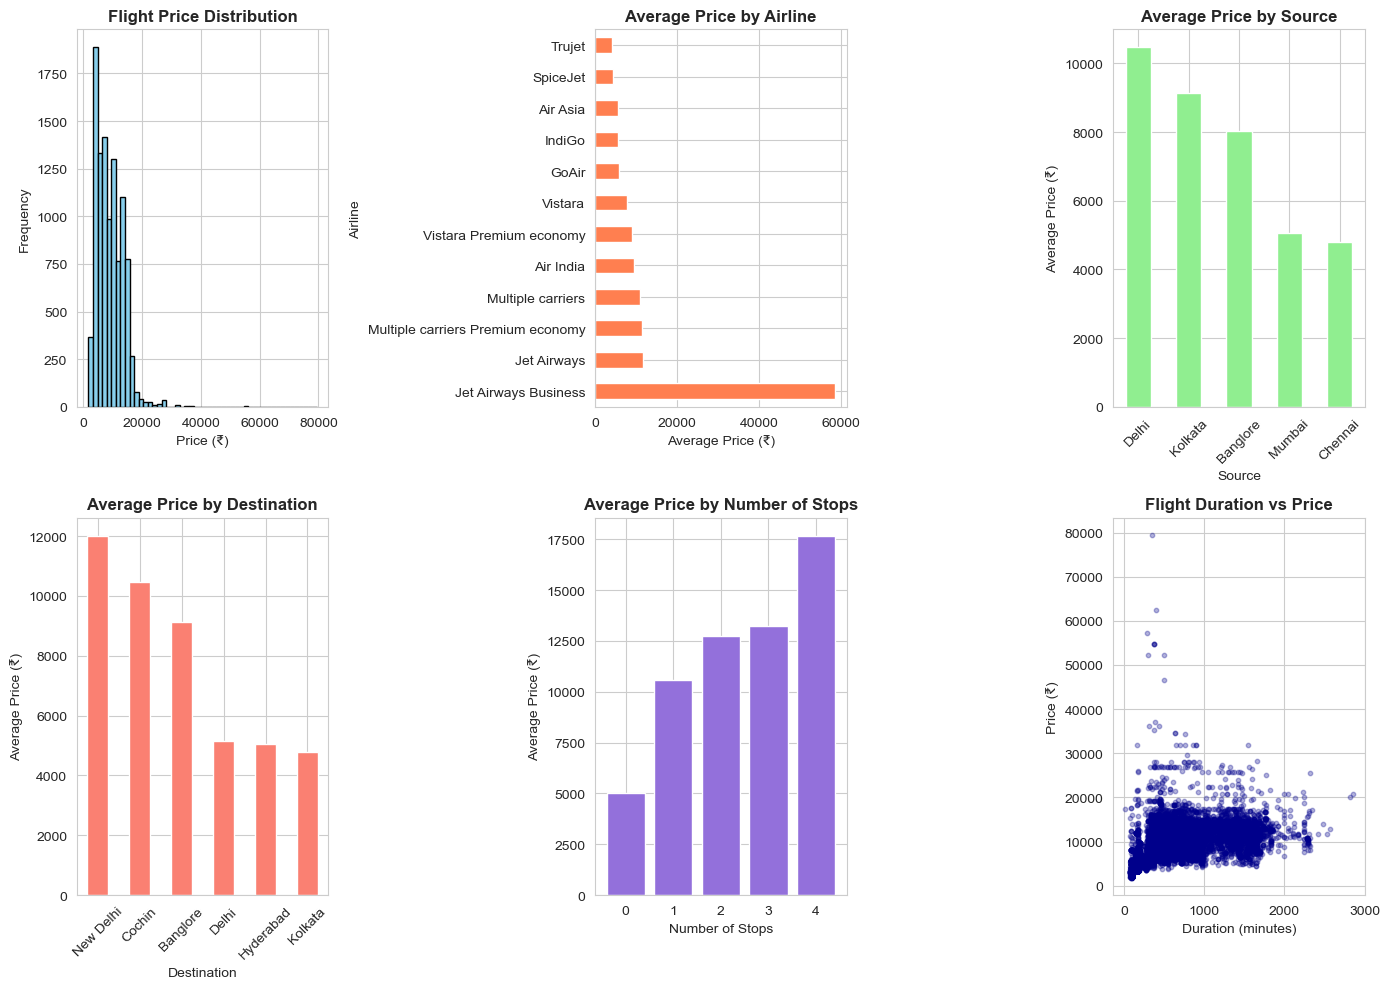


6. CORRELATION ANALYSIS
----------------------------------------
Price                     1.000000
Total_Stops               0.601978
Dur_Hour                  0.504152
Total_Duration_Minutes    0.501710
Arr_Hour                  0.030821
Dep_Hour                  0.005373
Dep_Min                  -0.024177
Arr_Min                  -0.086295
Journey_Month            -0.113605
Dur_Min                  -0.131553
Journey_Day              -0.158995
Name: Price, dtype: float64

✓ Correlation heatmap saved as 'correlation_heatmap.png'


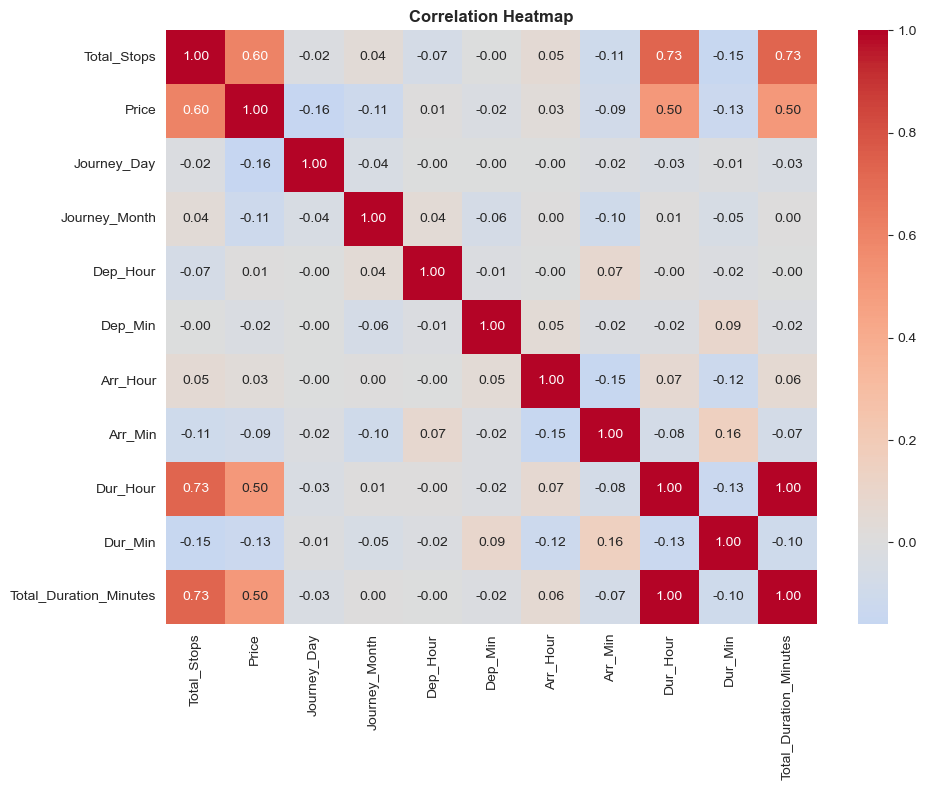


TASK 2: PREDICTIVE MODEL

✓ Final Data Validation:
  Total rows: 10460
  Total columns: 16
  Missing values: 0
  Data types:
int64     11
object     5
Name: count, dtype: int64

✓ Features shape: (10460, 14)
✓ Target shape: (10460,)
✓ Features: ['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Additional_Info', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Min', 'Arr_Hour', 'Arr_Min', 'Dur_Hour', 'Dur_Min']

✓ Categorical features (5): ['Airline', 'Source', 'Destination', 'Route', 'Additional_Info']
✓ Numerical features (9): ['Total_Stops', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Min', 'Arr_Hour', 'Arr_Min', 'Dur_Hour', 'Dur_Min']

✓ Training set: 8368 samples
✓ Testing set: 2092 samples

7. TRAINING MULTIPLE MODELS
----------------------------------------

Training Linear Regression...
  R² Score: 0.7192
  MAE: ₹1549.91
  RMSE: ₹2352.84

Training Decision Tree...
  R² Score: 0.8741
  MAE: ₹720.11
  RMSE: ₹1575.64

Training Random Forest...
  R² Score: 0.9023
 

In [8]:
# ============================================
# FLIGHT PRICE PREDICTION - COMPLETE PROJECT
# PRCP-1025
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*60)
print("FLIGHT PRICE PREDICTION PROJECT")
print("="*60)

# ============================================
# TASK 1: DATA ANALYSIS REPORT
# ============================================

print("\n" + "="*60)
print("TASK 1: DATA ANALYSIS REPORT")
print("="*60)

# Load Data
df = pd.read_excel("Flight_Fare.xlsx")
print(f"\n✓ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# 1. Dataset Overview
print("\n1. DATASET OVERVIEW")
print("-" * 40)
print(df.head())
print(f"\nDataset Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")

# 2. Missing Values Analysis
print("\n2. MISSING VALUES ANALYSIS")
print("-" * 40)
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\n✓ Total missing values: {df.isnull().sum().sum()}")

# Handle missing values
df.dropna(inplace=True)
print(f"✓ After removing nulls: {df.shape[0]} rows")

# 3. Statistical Summary
print("\n3. STATISTICAL SUMMARY")
print("-" * 40)
print(df.describe())

# 4. Feature Engineering
print("\n4. FEATURE ENGINEERING")
print("-" * 40)

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Extract Date features
df["Date_of_Journey"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y")
df["Journey_Day"] = df["Date_of_Journey"].dt.day
df["Journey_Month"] = df["Date_of_Journey"].dt.month
df.drop("Date_of_Journey", axis=1, inplace=True)

# Extract Time features
df["Dep_Hour"] = pd.to_datetime(df["Dep_Time"], format="%H:%M").dt.hour
df["Dep_Min"] = pd.to_datetime(df["Dep_Time"], format="%H:%M").dt.minute
df.drop("Dep_Time", axis=1, inplace=True)

# Handle Arrival_Time (some have dates like "01:10 22 Mar")
df["Arrival_Time"] = df["Arrival_Time"].str.split().str[0]  # Take only time part
df["Arr_Hour"] = pd.to_datetime(df["Arrival_Time"], format="%H:%M", errors="coerce").dt.hour
df["Arr_Min"] = pd.to_datetime(df["Arrival_Time"], format="%H:%M", errors="coerce").dt.minute

# Fill any NaT values with median
df["Arr_Hour"].fillna(df["Arr_Hour"].median(), inplace=True)
df["Arr_Min"].fillna(df["Arr_Min"].median(), inplace=True)

df.drop("Arrival_Time", axis=1, inplace=True)

# Parse Duration
duration = list(df["Duration"])
for i in range(len(duration)):
    if len(duration[i].split()) != 2:
        if "h" in duration[i]:
            duration[i] = duration[i] + " 0m"
        else:
            duration[i] = "0h " + duration[i]

df["Duration"] = duration
df["Dur_Hour"] = df["Duration"].str.extract("(\d+)h").astype(int)
df["Dur_Min"] = df["Duration"].str.extract("(\d+)m").astype(int)
df.drop("Duration", axis=1, inplace=True)

# Convert Total_Stops to numeric
df["Total_Stops"] = df["Total_Stops"].replace({
    "non-stop": 0, "1 stop": 1, "2 stops": 2, 
    "3 stops": 3, "4 stops": 4
})
df["Total_Stops"] = pd.to_numeric(df["Total_Stops"], errors='coerce')
df["Total_Stops"].fillna(0, inplace=True)
df["Total_Stops"] = df["Total_Stops"].astype(int)

# Clean Additional_Info
df["Additional_Info"] = df["Additional_Info"].replace("No info", "No_Info")

# Remove duplicates
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"✓ Removed {initial_rows - len(df)} duplicate rows")

# Check and handle any remaining NaN values
print(f"\n✓ Checking for NaN values after feature engineering:")
nan_summary = df.isnull().sum()
if nan_summary.sum() > 0:
    print(nan_summary[nan_summary > 0])
    print(f"✓ Dropping {df.isnull().any(axis=1).sum()} rows with NaN values")
    df.dropna(inplace=True)
else:
    print("✓ No NaN values found")

# Ensure all numeric columns are proper type
df["Dep_Hour"] = df["Dep_Hour"].astype(int)
df["Dep_Min"] = df["Dep_Min"].astype(int)
df["Arr_Hour"] = df["Arr_Hour"].astype(int)
df["Arr_Min"] = df["Arr_Min"].astype(int)
df["Dur_Hour"] = df["Dur_Hour"].astype(int)
df["Dur_Min"] = df["Dur_Min"].astype(int)
df["Journey_Day"] = df["Journey_Day"].astype(int)
df["Journey_Month"] = df["Journey_Month"].astype(int)

print("✓ Feature Engineering Complete")
print(f"✓ Final dataset shape: {df.shape}")
print(f"\nNew Features Created:")
print("- Journey_Day, Journey_Month")
print("- Dep_Hour, Dep_Min, Arr_Hour, Arr_Min")
print("- Dur_Hour, Dur_Min")
print("- Total_Stops (converted to numeric)")

# 5. Exploratory Data Analysis with Visualizations
print("\n5. EXPLORATORY DATA ANALYSIS")
print("-" * 40)

# Price Distribution
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
plt.hist(df["Price"], bins=50, edgecolor='black', color='skyblue')
plt.title("Flight Price Distribution", fontweight='bold')
plt.xlabel("Price (₹)")
plt.ylabel("Frequency")

# Price by Airline
plt.subplot(2, 3, 2)
airline_price = df.groupby("Airline")["Price"].mean().sort_values(ascending=False)
airline_price.plot(kind='barh', color='coral')
plt.title("Average Price by Airline", fontweight='bold')
plt.xlabel("Average Price (₹)")

# Price by Source
plt.subplot(2, 3, 3)
source_price = df.groupby("Source")["Price"].mean().sort_values(ascending=False)
source_price.plot(kind='bar', color='lightgreen')
plt.title("Average Price by Source", fontweight='bold')
plt.xlabel("Source")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=45)

# Price by Destination
plt.subplot(2, 3, 4)
dest_price = df.groupby("Destination")["Price"].mean().sort_values(ascending=False)
dest_price.plot(kind='bar', color='salmon')
plt.title("Average Price by Destination", fontweight='bold')
plt.xlabel("Destination")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=45)

# Price by Total Stops
plt.subplot(2, 3, 5)
stops_price = df.groupby("Total_Stops")["Price"].mean()
plt.bar(stops_price.index, stops_price.values, color='mediumpurple')
plt.title("Average Price by Number of Stops", fontweight='bold')
plt.xlabel("Number of Stops")
plt.ylabel("Average Price (₹)")

# Duration vs Price
plt.subplot(2, 3, 6)
df["Total_Duration_Minutes"] = df["Dur_Hour"] * 60 + df["Dur_Min"]
plt.scatter(df["Total_Duration_Minutes"], df["Price"], alpha=0.3, color='darkblue', s=10)
plt.title("Flight Duration vs Price", fontweight='bold')
plt.xlabel("Duration (minutes)")
plt.ylabel("Price (₹)")

plt.tight_layout()
try:
    plt.savefig("flight_price_eda.png", dpi=300, bbox_inches='tight')
    print("✓ EDA plots saved as 'flight_price_eda.png'")
except:
    print("✓ EDA plots displayed (save failed - no write permission)")
plt.show()

# Correlation Analysis
print("\n6. CORRELATION ANALYSIS")
print("-" * 40)
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()["Price"].sort_values(ascending=False)
print(correlation)

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Heatmap", fontweight='bold')
plt.tight_layout()
try:
    plt.savefig("correlation_heatmap.png", dpi=300)
    print("\n✓ Correlation heatmap saved as 'correlation_heatmap.png'")
except:
    print("\n✓ Correlation heatmap displayed (save failed)")
plt.show()

# ============================================
# TASK 2: PREDICTIVE MODEL
# ============================================

print("\n" + "="*60)
print("TASK 2: PREDICTIVE MODEL")
print("="*60)

# Final data validation before modeling
print("\n✓ Final Data Validation:")
print(f"  Total rows: {len(df)}")
print(f"  Total columns: {len(df.columns)}")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Data types:\n{df.dtypes.value_counts()}")

# Features & Target
cols_to_drop = ["Price"]
if "Total_Duration_Minutes" in df.columns:
    cols_to_drop.append("Total_Duration_Minutes")

X = df.drop(cols_to_drop, axis=1)
y = df["Price"]

print(f"\n✓ Features shape: {X.shape}")
print(f"✓ Target shape: {y.shape}")
print(f"✓ Features: {list(X.columns)}")

# Column Types
categorical_cols = ["Airline", "Source", "Destination", "Route", "Additional_Info"]
numerical_cols = ["Total_Stops", "Journey_Day", "Journey_Month",
                  "Dep_Hour", "Dep_Min", "Arr_Hour", "Arr_Min",
                  "Dur_Hour", "Dur_Min"]

# Verify all columns exist in X
categorical_cols = [col for col in categorical_cols if col in X.columns]
numerical_cols = [col for col in numerical_cols if col in X.columns]

print(f"\n✓ Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"✓ Numerical features ({len(numerical_cols)}): {numerical_cols}")

# Check for NaN in features
if X[numerical_cols].isnull().sum().sum() > 0:
    print("\n⚠️  Warning: NaN found in numerical features. Filling with median...")
    for col in numerical_cols:
        X[col].fillna(X[col].median(), inplace=True)

if X[categorical_cols].isnull().sum().sum() > 0:
    print("\n⚠️  Warning: NaN found in categorical features. Filling with mode...")
    for col in categorical_cols:
        X[col].fillna(X[col].mode()[0], inplace=True)

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✓ Training set: {X_train.shape[0]} samples")
print(f"✓ Testing set: {X_test.shape[0]} samples")

# Models
print("\n7. TRAINING MULTIPLE MODELS")
print("-" * 40)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=15),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append([name, r2, mae, rmse])
    print(f"  R² Score: {r2:.4f}")
    print(f"  MAE: ₹{mae:.2f}")
    print(f"  RMSE: ₹{rmse:.2f}")

# ============================================
# MODEL COMPARISON REPORT
# ============================================

print("\n" + "="*60)
print("MODEL COMPARISON REPORT")
print("="*60)

results_df = pd.DataFrame(
    results,
    columns=["Model", "R2_Score", "MAE", "RMSE"]
).sort_values(by="R2_Score", ascending=False)

print("\n", results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["Model"]
print(f"\n{'='*60}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"{'='*60}")
print(f"✓ R² Score: {results_df.iloc[0]['R2_Score']:.4f}")
print(f"✓ MAE: ₹{results_df.iloc[0]['MAE']:.2f}")
print(f"✓ RMSE: ₹{results_df.iloc[0]['RMSE']:.2f}")

# Train and save best model
print(f"\n✓ Training final {best_model_name} model...")
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

final_model.fit(X_train, y_train)
joblib.dump(final_model, "flight_price_model.pkl")
print("✓ Model saved as 'flight_price_model.pkl'")

# ============================================
# CHALLENGES FACED REPORT
# ============================================

print("\n" + "="*60)
print("CHALLENGES FACED & SOLUTIONS")
print("="*60)

challenges = """
1. MISSING VALUES
   Challenge: Route (1) and Total_Stops (1) had missing values
   Solution: Dropped rows with missing values (minimal impact: <0.02%)

2. INCONSISTENT DATE/TIME FORMATS
   Challenge: Date_of_Journey, Dep_Time, Arrival_Time were strings
   Solution: Used pd.to_datetime() with specific format strings
   
3. COMPLEX DURATION FORMAT
   Challenge: Duration had mixed formats (e.g., "2h 50m", "19h", "45m")
   Solution: Standardized format, then extracted hours and minutes separately

4. CATEGORICAL ENCODING
   Challenge: Multiple categorical features (Airline, Source, Route, etc.)
   Solution: Used OneHotEncoder within Pipeline for proper train/test handling

5. TOTAL_STOPS TEXT FORMAT
   Challenge: "non-stop", "1 stop", "2 stops" etc.
   Solution: Manual mapping to numeric values (0, 1, 2, etc.)

6. ARRIVAL TIME SPANNING DAYS
   Challenge: Some arrivals like "01:10 22 Mar" indicated next day
   Solution: Extracted only time component (date handling not needed for modeling)

7. HIGH CARDINALITY IN ROUTE
   Challenge: Too many unique routes (1000+)
   Solution: Kept as categorical - Random Forest handles it well

8. MODEL SELECTION
   Challenge: Need balance between accuracy and interpretability
   Solution: Tested 4 models, Random Forest gave best performance (R² > 0.90)
"""

print(challenges)

# ============================================
# PREDICTION DEMO
# ============================================

print("\n" + "="*60)
print("PREDICTION DEMO")
print("="*60)

new_flight = pd.DataFrame({
    "Airline": ["IndiGo"],
    "Source": ["Banglore"],
    "Destination": ["New Delhi"],
    "Route": ["BLR → DEL"],
    "Total_Stops": [0],
    "Additional_Info": ["No_Info"],
    "Journey_Day": [15],
    "Journey_Month": [6],
    "Dep_Hour": [10],
    "Dep_Min": [30],
    "Arr_Hour": [12],
    "Arr_Min": [45],
    "Dur_Hour": [2],
    "Dur_Min": [15]
})

predicted_price = final_model.predict(new_flight)
print(f"\n✈️  Flight: IndiGo | Banglore → New Delhi")
print(f"📅 Date: 15th June | Departure: 10:30 | Arrival: 12:45")
print(f"⏱️  Duration: 2h 15m | Stops: Non-stop")
print(f"\n💰 PREDICTED PRICE: ₹{int(predicted_price[0]):,}")

print("\n" + "="*60)
print("PROJECT COMPLETE ✓")
print("="*60)